In [1]:
%matplotlib widget

import os
import sys
import glob
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import RectangleSelector

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)
    
from utils.paths import ICOS_CITIES_LEVEL_1

assert (os.path.exists(ICOS_CITIES_LEVEL_1))

In [2]:
# load csv files
L1_filenames = glob.glob(os.path.join(ICOS_CITIES_LEVEL_1, '*.csv'))

for path in L1_filenames:  
    pass
df = pl.read_csv(path, skip_rows=44, has_header=True, separator=';', try_parse_dates=True).filter(pl.col("Flag") == "U")

# Ensure it's Polars Datetime (us) and add stable row id
df = df.with_row_index("row_id").with_columns(
    pl.col("#Datetime").cast(pl.Datetime("us"))
)

# Global flags for the FULL df (persist across months)
flag = np.zeros(df.height, dtype=np.int8)

In [3]:
df

row_id,#Datetime,Year,Month,Day,Hour,Minute,Second,DecimalDate,co2,h2o,pressure,sensor_temperature,ws,wd,Flag
u32,datetime[μs],i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str
0,2024-02-22 00:00:30,2024,2,22,0,0,30,2024.142467,444.16,1.0,953.68,30.55,0.8,169.6,"""U"""
1,2024-02-22 00:01:30,2024,2,22,0,1,30,2024.142469,445.45,1.01,953.68,30.52,0.8,169.6,"""U"""
2,2024-02-22 00:02:30,2024,2,22,0,2,30,2024.142471,445.18,1.01,953.68,30.5,0.8,169.6,"""U"""
3,2024-02-22 00:03:30,2024,2,22,0,3,30,2024.142472,444.09,1.01,953.61,30.5,1.7,185.6,"""U"""
4,2024-02-22 00:04:30,2024,2,22,0,4,30,2024.142474,443.97,1.01,953.61,30.5,1.7,185.6,"""U"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
842224,2025-11-29 15:48:30,2025,11,29,15,48,30,2025.908903,442.95,0.81,954.98,17.83,0.9,148.7,"""U"""
842225,2025-11-29 15:49:30,2025,11,29,15,49,30,2025.908905,441.0,0.82,954.98,18.03,0.7,153.3,"""U"""
842226,2025-11-29 15:50:30,2025,11,29,15,50,30,2025.908907,441.55,0.83,954.98,18.17,0.7,153.3,"""U"""


In [4]:
def annotate_month(df: pl.DataFrame, flag: np.ndarray, year: int, month: int,
                   time_col="#Datetime", value_col="co2"):
    sub = (
        df.filter(
            (pl.col(time_col).dt.year() == year) &
            (pl.col(time_col).dt.month() == month)
        )
        .select(["row_id", time_col, value_col])
    )

    row_id = sub["row_id"].to_numpy()
    time_np = sub[time_col].to_numpy()   # datetime64
    val_np  = sub[value_col].to_numpy()

    # colors from global flag for those rows
    c = flag[row_id]

    fig, ax = plt.subplots(figsize=(12, 5))
    sc = ax.scatter(time_np, val_np, c=c, cmap="coolwarm", vmin=0, vmax=1, s=25)
    ax.set_title(f"Annotate {year}-{month:02d} (drag rectangle to flag)")
    ax.set_xlabel("Time")
    ax.set_ylabel(value_col)
    ax.set_xlim(time_np.min(), time_np.max())

    def on_select(eclick, erelease):
        x0, x1 = eclick.xdata, erelease.xdata
        y0, y1 = eclick.ydata, erelease.ydata
        if x0 is None or x1 is None or y0 is None or y1 is None:
            return

        t0 = np.datetime64(mdates.num2date(x0).replace(tzinfo=None))
        t1 = np.datetime64(mdates.num2date(x1).replace(tzinfo=None))
        tmin, tmax = sorted([t0, t1])
        ymin, ymax = sorted([y0, y1])

        mask = (time_np >= tmin) & (time_np <= tmax) & (val_np >= ymin) & (val_np <= ymax)

        # Flag selected points in the GLOBAL flag array
        flag[row_id[mask]] = 1

        # Update colors in this month plot
        sc.set_array(flag[row_id])
        fig.canvas.draw_idle()

    rect = RectangleSelector(ax, on_select, useblit=False, button=[1], interactive=True)
    fig._rect_selector = rect  # keep alive

    plt.show()
    #return fig  # optional, for later closing/inspection

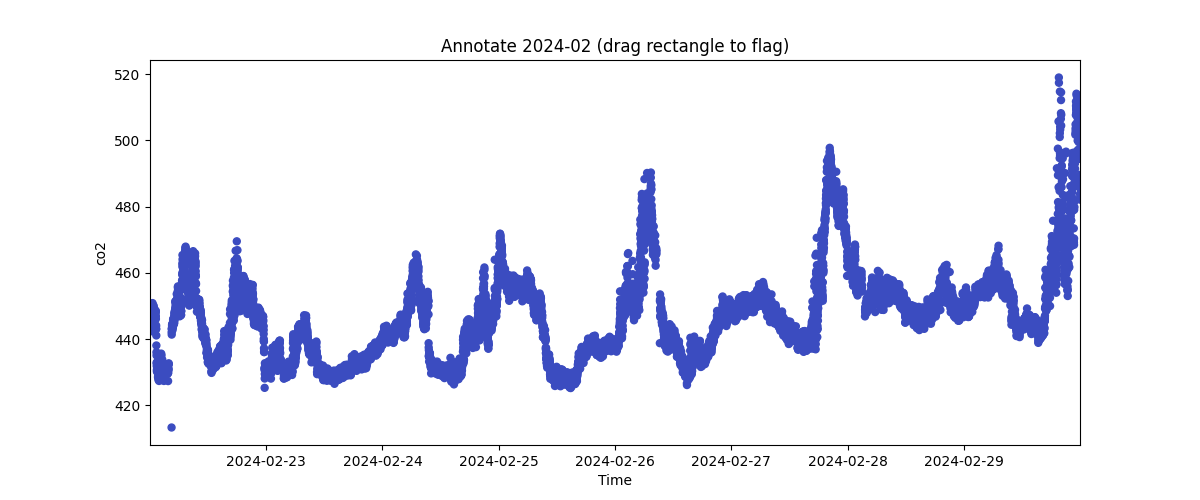

In [5]:
annotate_month(df, flag, 2024, 2)

In [6]:
df_flagged = df.with_columns(pl.Series("L2_Flag", flag))
df_flagged

row_id,#Datetime,Year,Month,Day,Hour,Minute,Second,DecimalDate,co2,h2o,pressure,sensor_temperature,ws,wd,Flag,L2_Flag
u32,datetime[μs],i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,i8
0,2024-02-22 00:00:30,2024,2,22,0,0,30,2024.142467,444.16,1.0,953.68,30.55,0.8,169.6,"""U""",0
1,2024-02-22 00:01:30,2024,2,22,0,1,30,2024.142469,445.45,1.01,953.68,30.52,0.8,169.6,"""U""",0
2,2024-02-22 00:02:30,2024,2,22,0,2,30,2024.142471,445.18,1.01,953.68,30.5,0.8,169.6,"""U""",0
3,2024-02-22 00:03:30,2024,2,22,0,3,30,2024.142472,444.09,1.01,953.61,30.5,1.7,185.6,"""U""",0
4,2024-02-22 00:04:30,2024,2,22,0,4,30,2024.142474,443.97,1.01,953.61,30.5,1.7,185.6,"""U""",0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
842224,2025-11-29 15:48:30,2025,11,29,15,48,30,2025.908903,442.95,0.81,954.98,17.83,0.9,148.7,"""U""",0
842225,2025-11-29 15:49:30,2025,11,29,15,49,30,2025.908905,441.0,0.82,954.98,18.03,0.7,153.3,"""U""",0
842226,2025-11-29 15:50:30,2025,11,29,15,50,30,2025.908907,441.55,0.83,954.98,18.17,0.7,153.3,"""U""",0
